In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('../data/raw/train_clean.csv')
data['Outstanding_Debt'] = data['Outstanding_Debt'] / 1000 # Scale to thousands
data = data.drop(columns=['Type_of_Loan'])
data.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Years,Spending_Level,Payment_Size
0,23.0,Scientist,19114.12,1824.843333,3,4,3.0,4.0,3,7.0,...,Good,0.80998,26.822620,No,82.054896,312.494089,Good,22.0,High,Small
1,23.0,Scientist,19114.12,1824.843333,3,4,3.0,4.0,4,4.0,...,Good,0.80998,31.944960,No,82.054896,284.629162,Good,22.0,Low,Large
2,23.0,Scientist,19114.12,1824.843333,3,4,3.0,4.0,3,7.0,...,Good,0.80998,28.609352,No,82.054896,331.209863,Good,22.0,Low,Medium
3,23.0,Scientist,19114.12,1824.843333,3,4,3.0,4.0,5,4.0,...,Good,0.80998,31.377862,No,82.054896,223.451310,Good,22.0,Low,Small
4,23.0,Scientist,19114.12,1824.843333,3,4,3.0,4.0,6,4.0,...,Good,0.80998,24.797347,No,82.054896,341.489231,Good,22.0,High,Medium


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90194 entries, 0 to 90193
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       90194 non-null  float64
 1   Occupation                90194 non-null  object 
 2   Annual_Income             90194 non-null  float64
 3   Monthly_Inhand_Salary     90194 non-null  float64
 4   Num_Bank_Accounts         90194 non-null  int64  
 5   Num_Credit_Card           90194 non-null  int64  
 6   Interest_Rate             90194 non-null  float64
 7   Num_of_Loan               90194 non-null  float64
 8   Delay_from_due_date       90194 non-null  int64  
 9   Num_of_Delayed_Payment    90194 non-null  float64
 10  Changed_Credit_Limit      90194 non-null  float64
 11  Num_Credit_Inquiries      90194 non-null  float64
 12  Credit_Mix                90194 non-null  object 
 13  Outstanding_Debt          90194 non-null  float64
 14  Credit

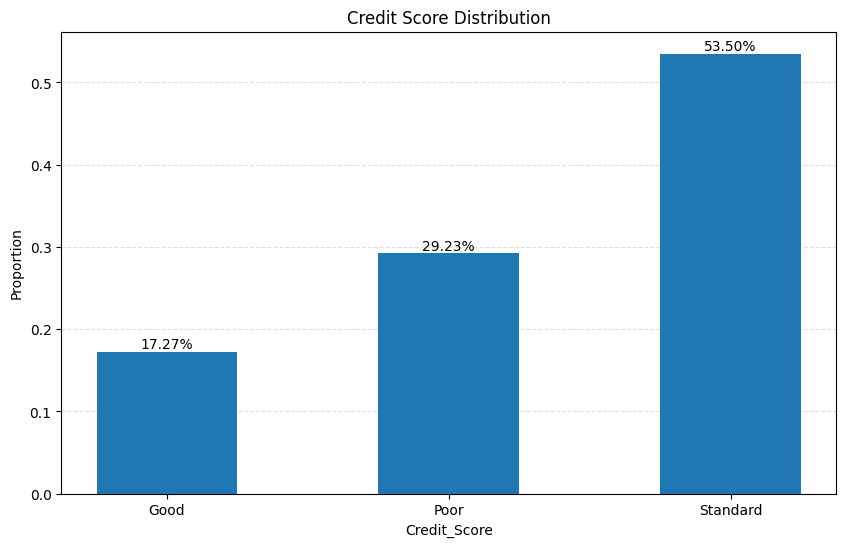

In [5]:
credit_score_dist = data['Credit_Score'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 6))
plt.bar(credit_score_dist.index, credit_score_dist.values, width=0.5, zorder=2)
for index, value in credit_score_dist.items():
    plt.text(index, value, f'{value:.2%}', ha='center', va='bottom')
plt.ylabel('Proportion')
plt.xlabel('Credit_Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.title('Credit Score Distribution')
plt.show()

In [6]:
# Value counts
data['Credit_Score'].value_counts()

Credit_Score
Standard    48253
Poor        26367
Good        15574
Name: count, dtype: int64

In [7]:
# Total entries
len(data)

90194

In [8]:
poor_data = data[data['Credit_Score'] == 'Poor']
good_data = data[data['Credit_Score'] == 'Good']
standard_data = data[data['Credit_Score'] == 'Standard']

In [9]:
poor_metadata = SingleTableMetadata()
poor_metadata.detect_from_dataframe(poor_data)
poor_metadata.save_to_json("../metadata/v3/poor_metadata.json")  

good_metadata = SingleTableMetadata()
good_metadata.detect_from_dataframe(good_data)
good_metadata.save_to_json("../metadata/v3/good_metadata.json")  

standard_metadata = SingleTableMetadata()
standard_metadata.detect_from_dataframe(standard_data)
standard_metadata.save_to_json("../metadata/v3/standard_metadata.json")  

# First trainings

In [53]:
synthesizer_poor = CTGANSynthesizer(
    metadata=poor_metadata,
    epochs=1000,
    batch_size=500,
    verbose=True
)
synthesizer_poor.fit(poor_data)

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto 2 CTGAN/venv/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Gen. (-01.82) | Discrim. (-00.13): 100%|██████████| 1000/1000 [36:57<00:00,  2.22s/it]


In [54]:
synthesizer_good = CTGANSynthesizer(
    metadata=good_metadata,
    epochs=1000,
    batch_size=500,
    verbose=True
)
synthesizer_good.fit(good_data)

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto 2 CTGAN/venv/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Gen. (-01.52) | Discrim. (+00.17): 100%|██████████| 1000/1000 [21:46<00:00,  1.31s/it]


In [55]:
sinthesizer_standard = CTGANSynthesizer(
    metadata=standard_metadata,
    epochs=1000,
    batch_size=500,
    verbose=True
)
sinthesizer_standard.fit(standard_data)

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto 2 CTGAN/venv/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Gen. (+01.23) | Discrim. (-00.08): 100%|██████████| 1000/1000 [1:09:25<00:00,  4.17s/it]


In [56]:
loss_poor = synthesizer_poor.get_loss_values()
loss_good = synthesizer_good.get_loss_values()
loss_standard = sinthesizer_standard.get_loss_values()

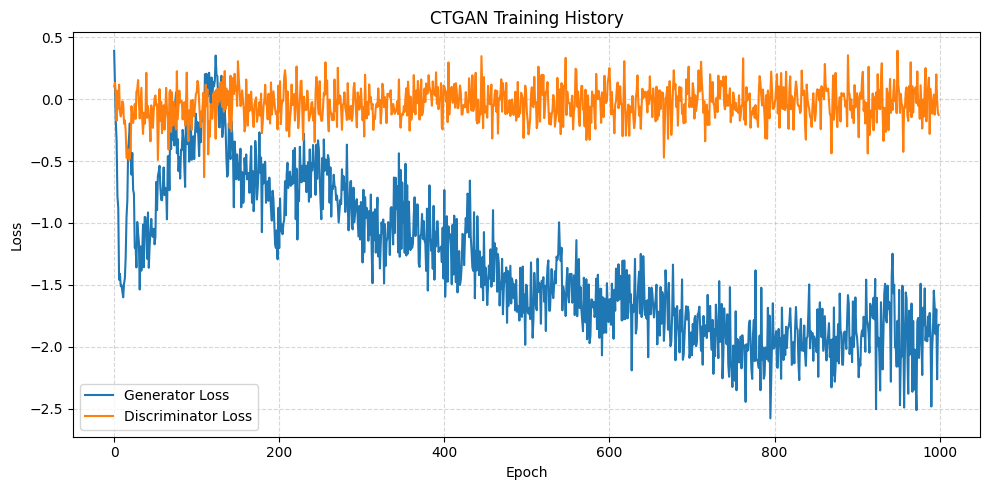

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_poor["Epoch"], loss_poor["Generator Loss"], label="Generator Loss")
ax.plot(loss_poor["Epoch"], loss_poor["Discriminator Loss"], label="Discriminator Loss")

ax.set_title("CTGAN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

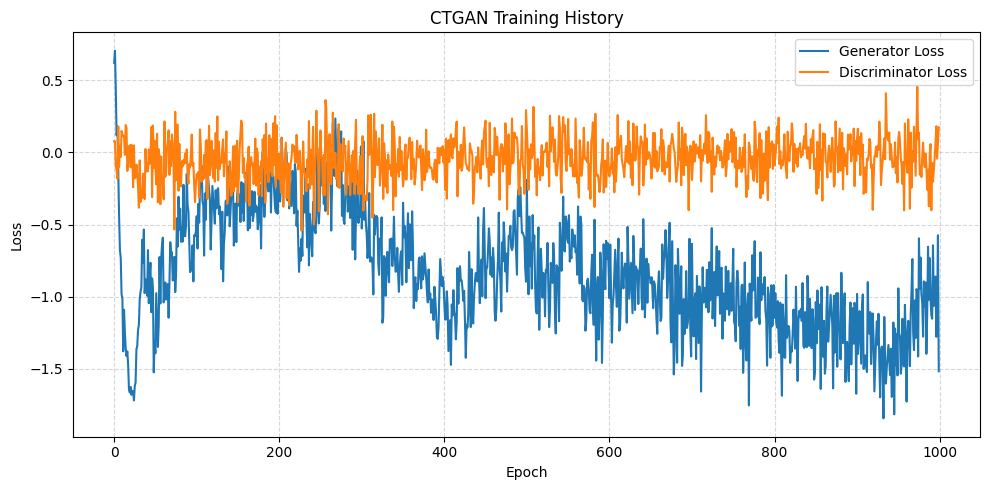

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_good["Epoch"], loss_good["Generator Loss"], label="Generator Loss")
ax.plot(loss_good["Epoch"], loss_good["Discriminator Loss"], label="Discriminator Loss")

ax.set_title("CTGAN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

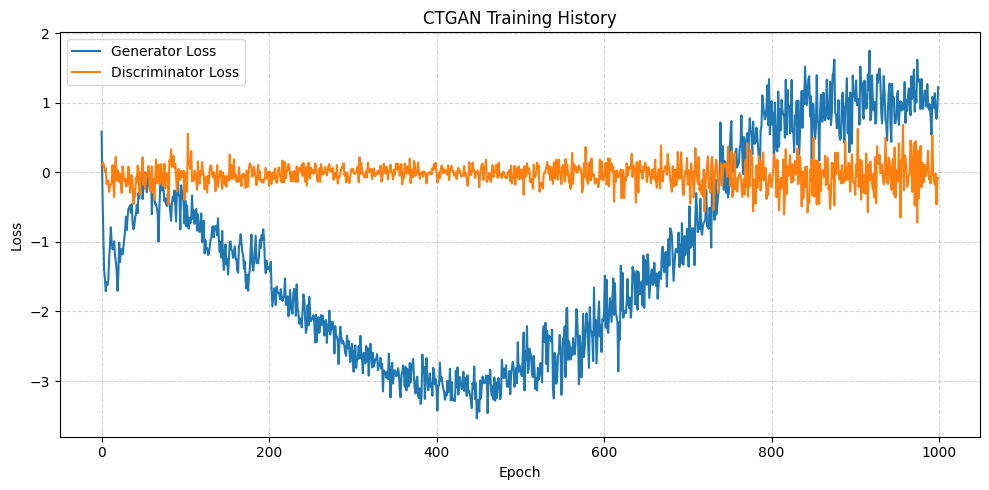

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_standard["Epoch"], loss_standard["Generator Loss"], label="Generator Loss")
ax.plot(loss_standard["Epoch"], loss_standard["Discriminator Loss"], label="Discriminator Loss")

ax.set_title("CTGAN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# New tries

In [11]:
data = pd.read_csv('../data/raw/train_clean.csv')
data['Outstanding_Debt'] = data['Outstanding_Debt'] / 1000 # Scale to thousands
data = data.drop(columns=['Type_of_Loan'])

train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data['Credit_Score'])

train_good_data = train[train['Credit_Score'] == 'Good']
train_poor_data = train[train['Credit_Score'] == 'Poor']
train_standard_data = train[train['Credit_Score'] == 'Standard']

# New metadata and synthesizers
train_good_metadata = SingleTableMetadata()
train_good_metadata.detect_from_dataframe(train_good_data)
train_good_metadata.save_to_json("../metadata/v4/train_good_metadata.json")

train_poor_metadata = SingleTableMetadata()
train_poor_metadata.detect_from_dataframe(train_poor_data)
train_poor_metadata.save_to_json("../metadata/v4/train_poor_metadata.json")

train_standard_metadata = SingleTableMetadata()
train_standard_metadata.detect_from_dataframe(train_standard_data)
train_standard_metadata.save_to_json("../metadata/v4/train_standard_metadata.json")

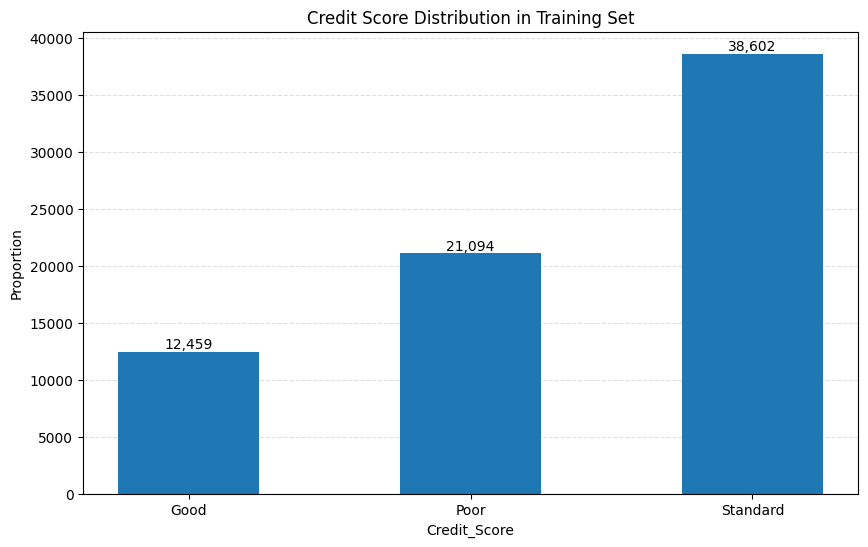

In [95]:
# Train credit score distribution
train_distr = train['Credit_Score'].value_counts(normalize=False).sort_index()
plt.figure(figsize=(10, 6))
plt.bar(train_distr.index, train_distr.values, width=0.5, zorder=2)
for index, value in train_distr.items():
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')
plt.ylabel('Proportion')
plt.xlabel('Credit_Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.title('Credit Score Distribution in Training Set')
plt.show()

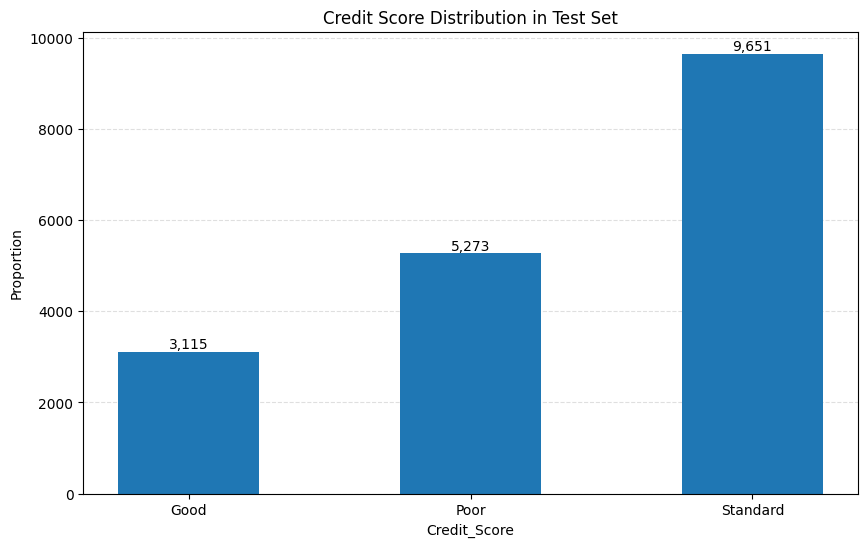

In [96]:
# Test distribution
test_distr = test['Credit_Score'].value_counts(normalize=False).sort_index()
plt.figure(figsize=(10, 6))
plt.bar(test_distr.index, test_distr.values, width=0.5, zorder=2)
for index, value in test_distr.items():
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')
plt.ylabel('Proportion')
plt.xlabel('Credit_Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.title('Credit Score Distribution in Test Set')
plt.show()

In [97]:
new_synth_standard = CTGANSynthesizer(
    metadata=train_standard_metadata,
    epochs=300,
    batch_size=2_000,
    discriminator_steps=5,
    verbose=True
)
new_synth_standard.fit(standard_data)

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto 2 CTGAN/venv/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Gen. (-00.48) | Discrim. (-00.27): 100%|██████████| 300/300 [28:49<00:00,  5.77s/it]


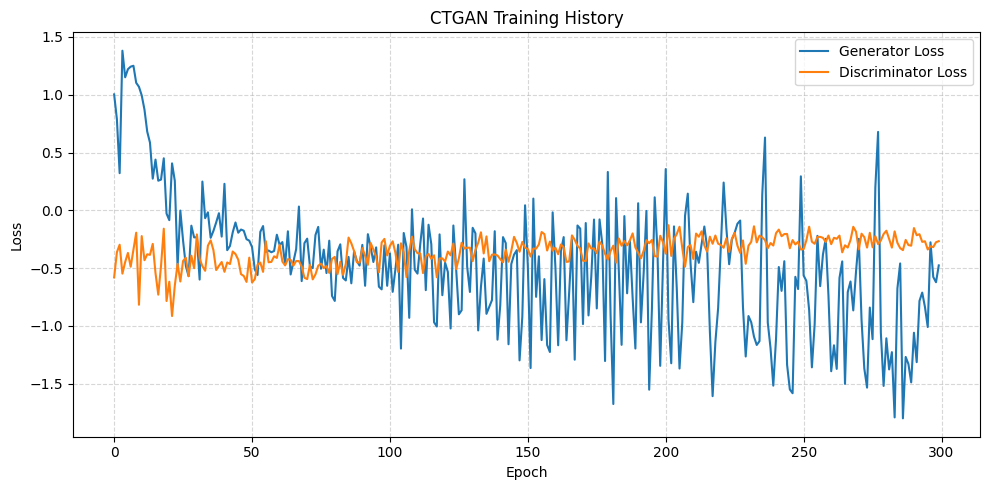

In [98]:
loss_new_standard = new_synth_standard.get_loss_values()
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_new_standard["Epoch"], loss_new_standard["Generator Loss"], label="Generator Loss")
ax.plot(loss_new_standard["Epoch"], loss_new_standard["Discriminator Loss"], label="Discriminator Loss")

ax.set_title("CTGAN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [99]:
new_synth_poor = CTGANSynthesizer(
    metadata=train_poor_metadata,
    epochs=300,
    batch_size=2_000,
    discriminator_steps=5,  
    verbose=True,
)
new_synth_poor.fit(poor_data)

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto 2 CTGAN/venv/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Gen. (-00.57) | Discrim. (-00.30): 100%|██████████| 300/300 [15:00<00:00,  3.00s/it]


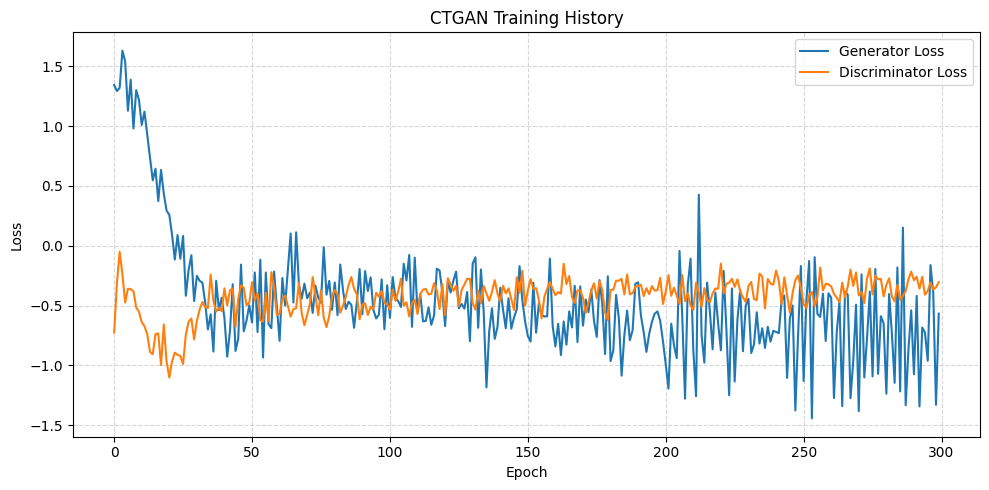

In [100]:
loss_new_poor = new_synth_poor.get_loss_values()
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_new_poor["Epoch"], loss_new_poor["Generator Loss"], label="Generator Loss")
ax.plot(loss_new_poor["Epoch"], loss_new_poor["Discriminator Loss"], label="Discriminator Loss")

ax.set_title("CTGAN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [101]:
new_synth_good = CTGANSynthesizer(
    metadata=train_good_metadata,
    epochs=300,
    batch_size=2_000,
    discriminator_steps=5,  
    verbose=True,
)
new_synth_good.fit(good_data)

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto 2 CTGAN/venv/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
Gen. (-00.30) | Discrim. (-00.42): 100%|██████████| 300/300 [08:56<00:00,  1.79s/it]


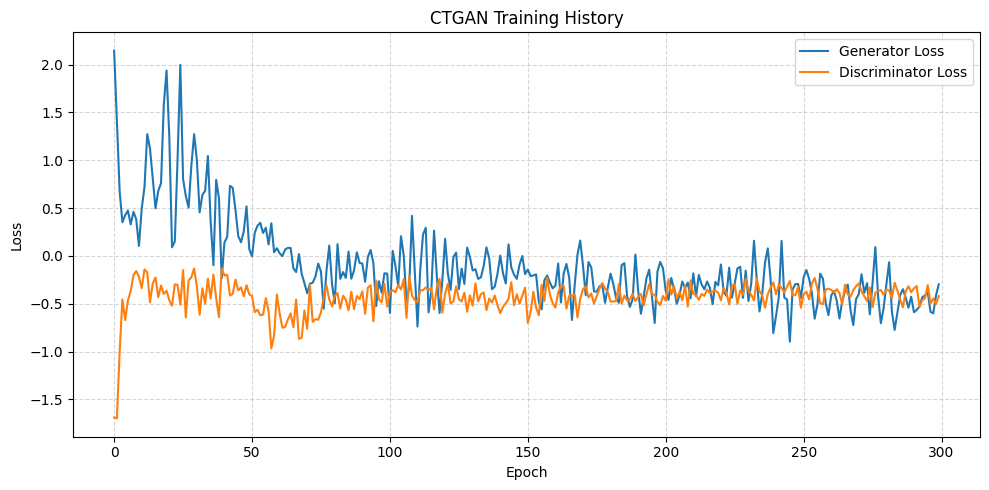

In [102]:
loss_new_good = new_synth_good.get_loss_values()
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_new_good["Epoch"], loss_new_good["Generator Loss"], label="Generator Loss")
ax.plot(loss_new_good["Epoch"], loss_new_good["Discriminator Loss"], label="Discriminator Loss")

ax.set_title("CTGAN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Save current models

In [ ]:
new_synth_good.save("../models/v4/synth_good.pkl")
new_synth_poor.save("../models/v4/synth_poor.pkl")
new_synth_standard.save("../models/v4/synth_standard.pkl")

# Load saved models

In [12]:
good_generator = CTGANSynthesizer.load("../models/v4/synth_good.pkl")
poor_generator = CTGANSynthesizer.load("../models/v4/synth_poor.pkl")
standard_generator = CTGANSynthesizer.load("../models/v4/synth_standard.pkl")

/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto2_Deep_Learning-/venv/lib/python3.13/site-packages/sdv/_utils.py:503: FutureWarning: The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.
  warnings.warn(
/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto2_Deep_Learning-/venv/lib/python3.13/site-packages/sdv/_utils.py:503: FutureWarning: The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.
  warnings.warn(
/Users/luisejdm/Documents/ITESO/8vo Semestre/Deep Learning/Proyecto2_Deep_Learning-/venv/lib/python3.13/site-packages/sdv/_utils.py:503: FutureWarning: The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.
  warnings.warn(


In [13]:
n = 30_000

synth_good = good_generator.sample(n)
synth_poor = poor_generator.sample(n)
synth_standard = standard_generator.sample(n)

In [106]:
full_data = pd.concat([synth_good, synth_poor, synth_standard], ignore_index=True)
full_data

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Years,Spending_Level,Payment_Size
0,23.0,Teacher,10308.286614,863.087262,0,5,8.0,3.0,14,8.0,...,Good,1.305876,23.314148,No,173.735988,72.530304,Good,21.0,Low,Small
1,30.0,Entrepreneur,18969.999177,1403.989542,8,9,22.0,6.0,47,8.0,...,Bad,4.395414,42.047232,Yes,46.878183,160.108278,Good,3.0,Missing,Large
2,33.0,Engineer,34556.814474,3160.244867,3,5,12.0,4.0,18,8.0,...,Good,0.244353,31.268347,NM,121.189331,226.243890,Good,25.0,High,Medium
3,25.0,Manager,28108.461725,1290.594855,3,6,12.0,4.0,30,15.0,...,Standard,0.907488,41.837294,Yes,88.391113,300.347903,Good,31.0,High,Medium
4,39.0,Engineer,101998.053383,7364.600437,4,7,8.0,4.0,4,2.0,...,Good,1.306347,41.050661,No,308.669134,1188.790230,Good,27.0,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,29.0,Doctor,111314.615068,12082.739239,3,7,6.0,2.0,3,7.0,...,Good,1.219914,39.412864,No,349.110893,1006.497267,Standard,16.0,High,Medium
89996,37.0,Mechanic,55463.938151,586.527087,6,5,34.0,2.0,9,18.0,...,Bad,2.464463,40.210457,Yes,232.529606,285.563030,Standard,1.0,Missing,Missing
89997,43.0,Lawyer,58524.107421,5636.804546,7,6,15.0,5.0,5,20.0,...,Standard,0.564139,35.280184,NM,256.087021,678.941302,Standard,15.0,Missing,Missing
89998,35.0,Musician,17231.078050,1070.804365,9,4,27.0,7.0,17,22.0,...,Bad,2.399894,28.877689,Yes,81.424231,249.261069,Standard,16.0,Low,Medium


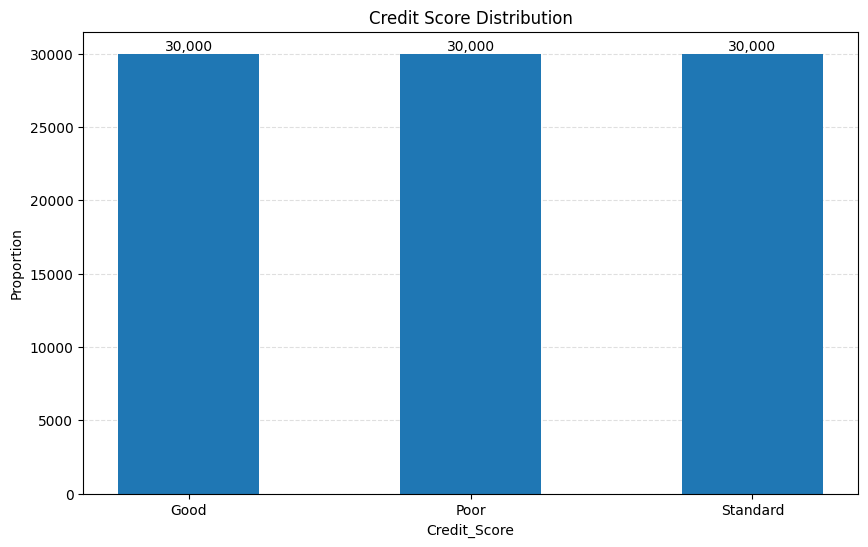

In [109]:
credit_score_dist_synth = full_data['Credit_Score'].value_counts(normalize=False).sort_index()

plt.figure(figsize=(10, 6))
plt.bar(credit_score_dist_synth.index, credit_score_dist_synth.values, width=0.5, zorder=2)
for index, value in credit_score_dist_synth.items():
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')
plt.ylabel('Proportion')
plt.xlabel('Credit_Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.title('Credit Score Distribution')
plt.show()

In [110]:
# Shuffle the data
shuffle_data = full_data.sample(frac=1, random_state=42).reset_index(drop=True)
shuffle_data.head(25)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Years,Spending_Level,Payment_Size
0,43.0,Accountant,58989.733478,6536.755160,4,4,17.0,1.0,17,17.0,...,Standard,0.115153,33.139240,Yes,253.978830,302.643193,Standard,26.0,High,Missing
1,39.0,Musician,59134.221330,8604.457643,3,2,3.0,2.0,7,12.0,...,Good,0.684705,30.940947,No,390.128999,265.840752,Good,18.0,Low,Small
2,27.0,Lawyer,11556.177589,570.004002,6,5,25.0,4.0,18,12.0,...,Standard,2.615715,28.112932,Yes,72.690003,300.067891,Poor,12.0,Missing,Missing
3,27.0,Accountant,8522.071846,966.506578,7,7,22.0,0.0,33,15.0,...,Bad,3.673349,34.626534,Yes,43.876607,308.330632,Standard,12.0,Low,Medium
4,32.0,Writer,10942.324988,9288.126035,3,6,6.0,0.0,9,6.0,...,Good,0.765386,27.738060,No,101.947103,339.025305,Standard,18.0,High,Large
5,46.0,Accountant,135461.282973,10719.965715,4,5,12.0,3.0,14,11.0,...,Standard,0.327305,24.266344,No,364.787005,964.472016,Good,23.0,High,Medium
6,17.0,Scientist,45043.159461,3563.314864,8,6,6.0,2.0,26,18.0,...,Standard,0.510813,33.800505,Yes,205.392266,270.633212,Standard,16.0,High,Large
7,37.0,Engineer,18018.731285,1463.362102,8,8,30.0,8.0,62,13.0,...,Bad,4.330252,27.398300,Yes,86.434534,307.013380,Good,3.0,High,Small
8,19.0,Teacher,33837.565730,3280.429666,3,4,6.0,0.0,4,5.0,...,Good,0.451248,31.746374,No,151.950574,616.704101,Standard,17.0,High,Medium
9,47.0,Accountant,13044.983767,1086.911351,3,4,10.0,4.0,7,5.0,...,Standard,1.328110,30.643485,Yes,54.044662,271.291198,Good,14.0,Missing,Medium


In [ ]:
# Export csv
shuffle_data.to_csv('../data/processed/v4/synthetic_train_data.csv', index=False)

In [ ]:
train.to_csv('../data/processed/v4/real_train_data.csv', index=False)
test.to_csv('../data/processed/v4/real_test_data.csv', index=False)